# Visualizing Graph Interactions with Chord Diagrams

Chord diagrams are a visually pleasing way to display complex interactions ("chords," "links," or "edges") between entities ("arcs" or "nodes") of a dataset. They are particularly useful for analyzing data involving systems of interacting bodies such as in population dynamics, economic modeling, and molecular simulation. The width of each chord of a chord diagram is scaled by interaction magnitude and organized hierarchically to make it easier to identify key interactions and trends.

In [ ]:
# Install the pyCirclize package to your conda enviornment:

%pip install pycirclize

In [3]:
from pycirclize import Circos
import seaborn as sns
import pandas as pd
import numpy as np

In [12]:
# Approximate H-bond fraction (%) values visually estimated from
# Li & Minkara, Biophysical Journal (2025), DOI:10.1016/j.bpj.2025.04.007, Figure 4.
# NOT the authors' original data — coarse color-matched estimates for teaching only.

residues = [
    "GLU_321", "ASN_323", "ASP_325", "GLU_329", "GLU_333",
    "THR_336", "ASN_341", "ARG_343", "GLU_347", "ARG_349",
]

glycans = [
    "MANa16MAN", "MANa13MAN", "MANa12MAN", "GLCa12GLC", "GLCa13GLC",
    "NAGb12MAN", "NAGb14MAN", "NAGb16MAN", "SIAa26GAL", "SIAa23GAL",
    "GALb14NAG", "FUCa16NAG", "MANa12MANa16MAN", "MANa12MANa12MAN",
    "MANa12MANa13MAN", "GLCa12GLCa13GLC", "GLCa13GLCa12GLC",
    "NAGb14NAG", "SIAa26GALb14NAG", "SIAa23GALb14NAG",
    "GALb14NAGb16MAN", "GALb14NAGb12MAN", "NAGb12MANa13MAN",
    "NAGb12MANa16MAN", "NAGb14MANa13MAN", "NAGb16MANa13MAN",
    "NAGb16MANb16MAN",
]

# rows = residues (order above), cols = glycans (order above)
data = np.array([
    # GLU_321
    [ 80, 75, 75, 70, 100, 70,  70, 150, 70, 100, 100, 70, 140, 70, 70, 60, 70,  20,  10,  70,  60, 150, 70, 150, 165, 70, 190],
    # ASN_323
    [  5,  5, 10,  5,   5,  5,   5,   5,  5,   5,   5,  5,   5,  5,  5,  5,  5,   5,   5,   5,   5,   5,  5,   5,   5,  5,   5],
    # ASP_325
    [ 40, 15, 90, 15,  50, 15,  90,  15, 50,  15,  15, 15, 100, 15, 15, 15, 70, 140,  15,  15,  40,  15, 15,  90, 90, 90,  15],
    # GLU_329
    [100,100,150, 30,  90, 90,  90, 100, 90, 100,  90, 90, 100, 30, 90, 30, 90,  30,  30,  70,  40,  30, 30, 100,100,100,  30],
    # GLU_333
    [ 10, 10, 10, 10,  55, 10,  50,  10, 10,  10,  10, 10,  10, 10,100, 10, 10,  10,  40,  10,  40,  10, 10,  15, 15, 15,  10],
    # THR_336
    [  3,  3,  3,  3,   3,  3,   3,   3,  3,   3,   3,  3,   3,  3,  3,  3,  3,   3,   3,   3,   3,   3,  3,   3,  3,  3,   3],
    # ASN_341
    [110,110,110, 30, 130,130, 110,  30,110, 110,  30,110,  30,110, 70, 30, 90,  30,  70,  30,  60, 150, 60, 100,100,100, 100],
    # ARG_343
    [ 15, 15, 15, 15,  95, 15,  90,  15, 85,  15,  90, 15,  15, 15,135, 15, 15,  15,  90,  90, 140, 150, 15,  90,140, 70,  90],
    # GLU_347
    [  5,  5,  5,  5,   5,  5,   5,   5,  5,   5,   5,  5,   5,  5,  5,  5,  5,   5,  50,   5,   5, 190,  5,   5,  5,  5,   5],
    # ARG_349
    [  5,  5,  5,  5,   5,  5,   5,   5,  5,   5,   5,  5,   5,  5,  5,  5,  5,   5,  55,   5,   5, 155,  5,  40,  5,  5,   5],
])

df = pd.DataFrame(data, index=residues, columns=glycans)
df.head()

,MANa16MAN,MANa13MAN,MANa12MAN,GLCa12GLC,GLCa13GLC,NAGb12MAN,NAGb14MAN,NAGb16MAN,SIAa26GAL,SIAa23GAL,GALb14NAG,FUCa16NAG,MANa12MANa16MAN,MANa12MANa12MAN,MANa12MANa13MAN,GLCa12GLCa13GLC,GLCa13GLCa12GLC,NAGb14NAG,SIAa26GALb14NAG,SIAa23GALb14NAG,GALb14NAGb16MAN,GALb14NAGb12MAN,NAGb12MANa13MAN,NAGb12MANa16MAN,NAGb14MANa13MAN,NAGb16MANa13MAN,NAGb16MANb16MAN
GLU_321,80,75,75,70,100,70,70,150,70,100,100,70,140,70,70,60,70,20,10,70,60,150,70,150,165,70,190
ASN_323,5,5,10,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
ASP_325,40,15,90,15,50,15,90,15,50,15,15,15,100,15,15,15,70,140,15,15,40,15,15,90,90,90,15
GLU_329,100,100,150,30,90,90,90,100,90,100,90,90,100,30,90,30,90,30,30,70,40,30,30,100,100,100,30
GLU_333,10,10,10,10,55,10,50,10,10,10,10,10,10,10,100,10,10,10,40,10,40,10,10,15,15,15,10


Text(0.5, 1.0, 'H-bonding between an SP-D lectin binding site and several glycan fragments')

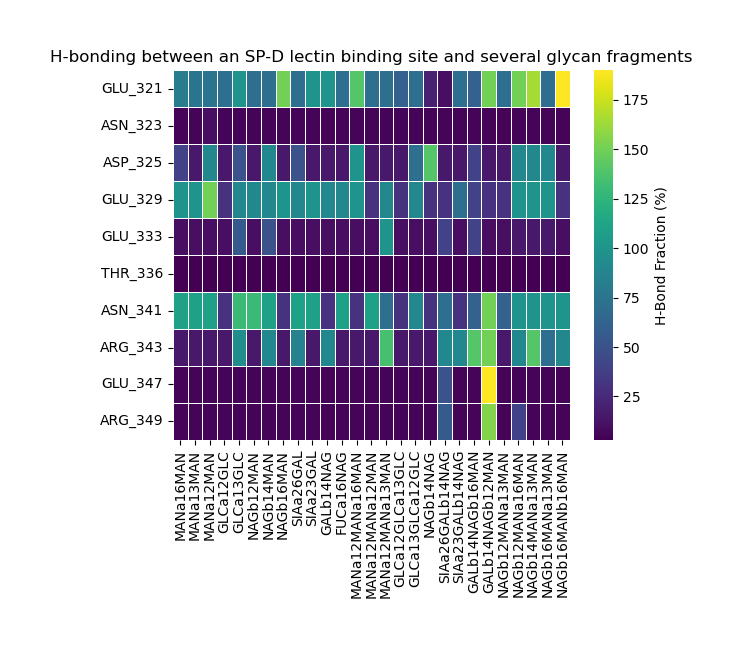

In [17]:
ax = sns.heatmap(
    data=df,
    cmap='viridis',
    cbar_kws={'label': 'H-Bond Fraction (%)'},
    linecolor='white',
    linewidth=.5,
)

ax.set_title('H-bonding between an SP-D lectin binding site and several glycan fragments')

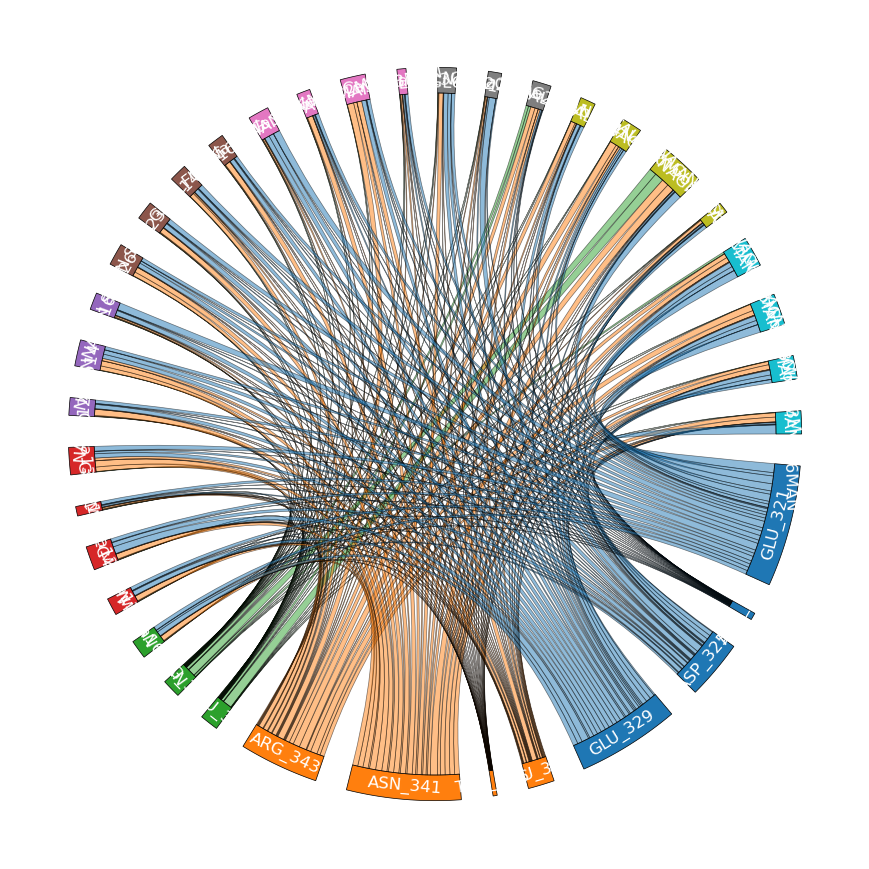

In [15]:
circos = Circos.chord_diagram(
    df,
    start=-265,
    end=95,
    space=5,
    r_lim=(93, 100),
    cmap="tab10",
    label_kws=dict(r=94, size=12, color="white"),
    link_kws=dict(ec="black", lw=0.5),
)

fig = circos.plotfig()

    E1  E2  E3  E4  E5  E6
S1   4  14  13  17   5   2
S2   7   1   6   8  12  15
S3   9  10   3  16  11  18


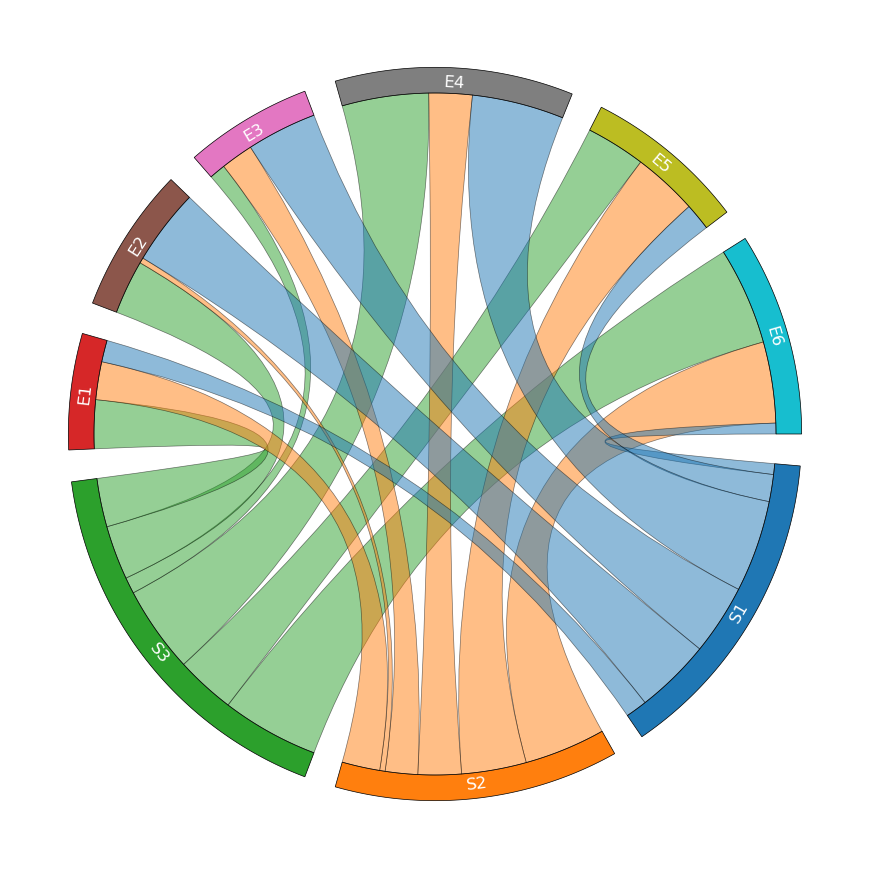

In [2]:
from pycirclize import Circos
import pandas as pd

# Create matrix dataframe (3 x 6)
row_names = ["S1", "S2", "S3"]
col_names = ["E1", "E2", "E3", "E4", "E5", "E6"]
matrix_data = [
    [4, 14, 13, 17, 5, 2],
    [7, 1, 6, 8, 12, 15],
    [9, 10, 3, 16, 11, 18],
]
matrix_df = pd.DataFrame(matrix_data, index=row_names, columns=col_names)

# Initialize Circos instance for chord diagram plot
circos = Circos.chord_diagram(
    matrix_df,
    start=-265,
    end=95,
    space=5,
    r_lim=(93, 100),
    cmap="tab10",
    label_kws=dict(r=94, size=12, color="white"),
    link_kws=dict(ec="black", lw=0.5),
)

print(matrix_df)
fig = circos.plotfig()

Resources:

- [Chord diagram plotting code from pyCirclize](https://moshi4.github.io/pyCirclize/chord_diagram/)
- [Frequency Chord diagram and Heatmap in Python](https://github.com/scverse/liana-py/issues/85)
- [Chord diagram example from Python Graph Gallery](https://python-graph-gallery.com/chord-diagram-python-chord/)
- [Chord diagrams of protein interaction networks in Python](https://medium.com/data-science/chord-diagrams-of-protein-interaction-networks-in-python-9589affc8b91)